# importing required libraries

In [31]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Input





## Data is splitted to training, validation and test folders

In [3]:
# Splitting the dataset into training, validation and test folders 
import splitfolders
input_folder="sign_language_interpreter/dataset - Gesture Speech"
output="sign_language_interpreter/dataset - Gesture Speech/Processed_data"
splitfolders.ratio(input_folder,output,seed=42,ratio=(.6,.2,.2))

Copying files: 31200 files [02:10, 238.65 files/s]


# Data augmentation and Data preprocessing 

In [32]:
# Defining Data augmentation and data preprocessing for Training data
train_datagen=ImageDataGenerator(
    # normalize the pixels to [0,1]
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
# Normalization alone applied for validation and test data
val_datagen=ImageDataGenerator(rescale=1./255)
test_datagen=ImageDataGenerator(rescale=1./255)



    

# Data loading

In [38]:
#reading files from the training folder
train_generator = train_datagen.flow_from_directory(
    "sign_language_interpreter/dataset - Gesture Speech/Processed_data/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# reading files from validation folder
val_generator = val_datagen.flow_from_directory(
    "sign_language_interpreter/dataset - Gesture Speech/Processed_data/val",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)
# reading files from test folder
test_generator = test_datagen.flow_from_directory(
    "sign_language_interpreter/dataset - Gesture Speech/Processed_data/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 18720 images belonging to 26 classes.
Found 6240 images belonging to 26 classes.
Found 6240 images belonging to 26 classes.


# CNN model

In [39]:

model = Sequential([
    Input(shape=(224, 224, 3)),   
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

# Compile the model

In [40]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model

In [41]:
history=model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 307s 522ms/step - accuracy: 0.3215 - loss: 2.4175 - val_accuracy: 0.8777 - val_loss: 0.4221
Epoch 2/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 305s 521ms/step - accuracy: 0.7025 - loss: 0.9440 - val_accuracy: 0.9269 - val_loss: 0.2562
Epoch 3/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 306s 523ms/step - accuracy: 0.7793 - loss: 0.6911 - val_accuracy: 0.9535 - val_loss: 0.1608
Epoch 4/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 306s 523ms/step - accuracy: 0.8149 - loss: 0.5702 - val_accuracy: 0.9591 - val_loss: 0.1214
Epoch 5/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 297s 508ms/step - accuracy: 0.8370 - loss: 0.4971 - val_accuracy: 0.9686 - val_loss: 0.1009
Epoch 6/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 293s 501ms/step - accuracy: 0.8585 - loss: 0.4330 - val_accuracy: 0.9792 - val_loss: 0.0718
Epoch 7/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 295s 504ms/step - accuracy: 0.8727 - loss: 0.3802 - val_accuracy: 0.9814 - val_loss: 0.0571
Epoch 8/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 297s 507ms/step - accuracy: 0.8783 -

## Evaluating the model

In [42]:
model.evaluate(test_generator)



195/195 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - accuracy: 0.9938 - loss: 0.0176    


[0.0209418423473835, 0.9929487109184265]

## Model Prediction

In [43]:
# predicting the labels
y_predict=model.predict(test_generator)

195/195 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step


In [44]:
y_predict[0]

array([9.9998474e-01, 2.8876989e-06, 4.0406917e-11, 7.9368847e-17,
       8.2032265e-13, 2.2294973e-09, 1.0741067e-19, 1.7228541e-25,
       3.7241521e-21, 1.0372689e-14, 1.2754677e-15, 8.7093927e-15,
       1.8924563e-13, 5.1707163e-11, 1.2385967e-05, 1.1037522e-10,
       1.1914804e-17, 8.6872059e-20, 5.7680209e-26, 3.9073657e-19,
       2.0725328e-11, 2.3392673e-16, 1.8352025e-23, 1.2277311e-11,
       4.5347027e-33, 8.0469163e-15], dtype=float32)

In [45]:
# using argmax, class label of the maximum array of each input is returned
import numpy as np
y_predicts=np.argmax(y_predict, axis=1)

In [46]:
y_predicts[2000:2010]

array([8, 8, 8, 8, 8, 8, 8, 8, 8, 8])

In [47]:
predicted_letters = [chr(i + ord('A')) for i in y_predicts]

In [48]:
print(predicted_letters[2000:2010])

['I', 'I', 'I', 'I', 'I', 'I', 'I', 'I', 'I', 'I']


In [49]:
class_names=train_generator.class_indices
class_names

{'a': 0,
 'b': 1,
 'c': 2,
 'd': 3,
 'e': 4,
 'f': 5,
 'g': 6,
 'h': 7,
 'i': 8,
 'j': 9,
 'k': 10,
 'l': 11,
 'm': 12,
 'n': 13,
 'o': 14,
 'p': 15,
 'q': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'w': 22,
 'x': 23,
 'y': 24,
 'z': 25}

## Confusion Matrix

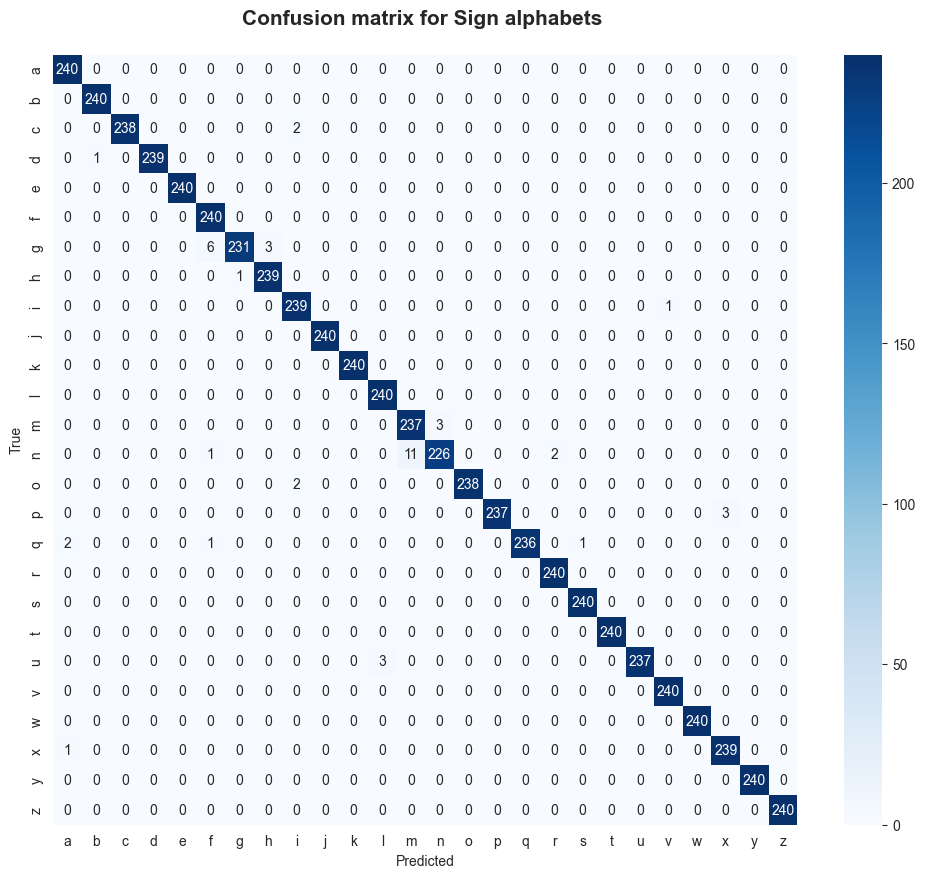

In [62]:
# confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
# True labels from your dataset
true_classes = test_generator.classes
con_mat=confusion_matrix(true_classes,y_predicts)
#visualizing confusion matrix
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette('deep')
# mentioning number of rows and columns, here we  have 0 to 9 i.e ten digits so ten rows and ten columns to display confusion matrix for actual and 
# predicted values
plt.figure(figsize=(12,10))
sns.heatmap(con_mat,annot=True,fmt="d",cmap="Blues",
            xticklabels=list(test_generator.class_indices.keys()),
            yticklabels=list(test_generator.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix for Sign alphabets \n", fontweight='bold',fontsize=15)
plt.show()

## Classification Report

In [65]:
print(classification_report(true_classes,y_predicts))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99       240
           1       1.00      1.00      1.00       240
           2       1.00      0.99      1.00       240
           3       1.00      1.00      1.00       240
           4       1.00      1.00      1.00       240
           5       0.97      1.00      0.98       240
           6       1.00      0.96      0.98       240
           7       0.99      1.00      0.99       240
           8       0.98      1.00      0.99       240
           9       1.00      1.00      1.00       240
          10       1.00      1.00      1.00       240
          11       0.99      1.00      0.99       240
          12       0.96      0.99      0.97       240
          13       0.99      0.94      0.96       240
          14       1.00      0.99      1.00       240
          15       1.00      0.99      0.99       240
          16       1.00      0.98      0.99       240
          17       0.99    